# 🧠 Intent Analyzer & Policy Engine — Interactive Code Flow & Guide

This notebook walks through the **Intent Analyzer** architecture, showing how customer intent signals are extracted, grounded against the real merchant catalog, and evaluated using pure deterministic Python policy rules before being passed to the **Merchant LLM**.

--- 

### 🔄 High-Level Architecture Flow

```
┌─────────────────────────────────────────────────────────────┐
│                     CUSTOMER MESSAGE                        │
└──────────────────────────────┬──────────────────────────────┘
                               │
                               ▼
                 [ selling_context_node ]
                               │
            ┌──────────────────┴──────────────────┐
            ▼                                     ▼
   [ Intent Analyzer ]                  [ Catalog Grounding ]
  • Budget Restrictiveness             • Search Wiki Pages
  • Quality Orientation                • Match Products
  • Upsell Openness                    • Extract Prices/Specs
  • Budget Stretch %                              │
            │                                     │
            └──────────────────┬──────────────────┘
                               │
                               ▼
                 [ Deterministic Policy Engine ]
                • Upsell Opportunity Score (0-100)
                • Hard Budget Boundary Override
                • Select Upsell Candidate
                • Select Cross-Sell Accessories
                               │
                               ▼
                    [ CommerceState Injected ]
                               │
                               ▼
                   [ Merchant LLM Response ]
```

In [1]:
import os
import sys
import json
from pathlib import Path
from dotenv import load_dotenv

# Configure root paths
backend_root = Path.cwd().parents[3] if 'merchant_llm' in str(Path.cwd()) else Path(r'c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend')
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

# Load environment
load_dotenv(str(backend_root / '.env'))
WIKI_PATH = str(backend_root / 'merchant_knowledge')

print('✓ Backend root loaded:', backend_root)
print('✓ Merchant Knowledge Wiki path:', WIKI_PATH)


✓ Backend root loaded: c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend
✓ Merchant Knowledge Wiki path: c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend\merchant_knowledge


## 1. Schema: `CustomerIntent`

The `CustomerIntent` model infers only psychological buying signals from conversational language, never making product decisions directly.

In [2]:
from src.agents.intent_analyzer_llm.schema import CustomerIntent

# Inspect schema fields
for field_name, field_info in CustomerIntent.model_fields.items():
    print(f' • {field_name} (default={field_info.default})')


 • budget_restrictiveness (default=0.5)
 • quality_value_orientation (default=0.5)
 • upsell_openness (default=0.5)
 • confidence (default=0.0)
 • acceptable_budget_stretch (default=None)
 • stated_budget (default=None)
 • hard_budget_constraint (default=False)
 • evidence (default=PydanticUndefined)


## 2. Deterministic Policy Functions (`policy.py`)

Policy logic is kept strictly in pure Python to guarantee safety and prevent LLM hallucination.

In [3]:
from src.agents.intent_analyzer_llm.policy import (
    calculate_upsell_score,
    calculate_budget_boundary,
    decide_upsell,
    select_upsell_candidate,
    decide_cross_sell
)

# Example: Calculating Upsell Opportunity Score
score = calculate_upsell_score(
    budget_restrictiveness=0.2,   # Flexible
    quality_value_orientation=0.9, # Highly values quality
    upsell_openness=0.8           # Open to stretch
)
decision = decide_upsell(score, hard_budget_constraint=False)

print(f'Calculated Upsell Score: {score}/100')
print(f'Policy Decision: {decision}')


Calculated Upsell Score: 83.0/100
Policy Decision: ACTIVE_UPSELL


## 3. End-to-End Test Scenarios

Let's test common customer scenarios through the analyzer flow.

In [4]:
from langchain_core.messages import HumanMessage
from src.agents.intent_analyzer_llm.analyzer import _analyze_selling_context

def analyze_query(query: str):
    state = {'messages': [HumanMessage(content=query)]}
    res = _analyze_selling_context(state, WIKI_PATH)
    print(f"\n💬 Customer Input: '{query}'")
    print(f"   • Stated Budget          : Rs {res['stated_budget']}")
    print(f"   • Effective Budget Limit : Rs {res['effective_budget']}")
    print(f"   • Upsell Score           : {res['upsell_opportunity_score']}/100")
    print(f"   • Upsell Decision        : {res['upsell_decision']}")
    if res['recommended_product']:
        print(f"   • Recommended Upgrade    : {res['recommended_product']['name']} (Rs {res['recommended_product']['price']})")
    print(f"   • Candidate Matches Found: {len(res['candidate_products'])}")
    return res

# Scenario 1: Customer wants cheapest possible product
analyze_query('Show me the cheapest possible phone available around Rs 10000.')

# Scenario 2: Customer has flexible budget & wants top quality
analyze_query('I want a top quality watch, flexible budget and willing to stretch extra Rs 5000 for something genuinely better.')

# Scenario 3: Hard budget refusal (Safety constraint)
analyze_query('I need a watch under Rs 4000. Do not show anything above that price, not a single rupee more.')

# Scenario 4: Non-existent product
analyze_query('I want to buy a flying hoverboard rocket jetpack for Rs 50000.')


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond



💬 Customer Input: 'Show me the cheapest possible phone available around Rs 10000.'
   • Stated Budget          : Rs 10000.0
   • Effective Budget Limit : Rs 10000.0
   • Upsell Score           : 8.5/100
   • Upsell Decision        : NO_UPSELL
   • Recommended Upgrade    : Iphone 15 Pro (Rs 1498.0)
   • Candidate Matches Found: 2


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond



💬 Customer Input: 'I want a top quality watch, flexible budget and willing to stretch extra Rs 5000 for something genuinely better.'
   • Stated Budget          : Rs None
   • Effective Budget Limit : Rs None
   • Upsell Score           : 72.5/100
   • Upsell Decision        : ACTIVE_UPSELL
   • Recommended Upgrade    : Kids Kids Stretch Denim Overalls 13 (Rs 839.0)
   • Candidate Matches Found: 5


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond



💬 Customer Input: 'I need a watch under Rs 4000. Do not show anything above that price, not a single rupee more.'
   • Stated Budget          : Rs 4000.0
   • Effective Budget Limit : Rs 4000.0
   • Upsell Score           : 15.0/100
   • Upsell Decision        : NO_UPSELL
   • Recommended Upgrade    : Apex Active Pulse Gps Watch 12 (Rs 95.0)
   • Candidate Matches Found: 6


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond



💬 Customer Input: 'I want to buy a flying hoverboard rocket jetpack for Rs 50000.'
   • Stated Budget          : Rs 50000.0
   • Effective Budget Limit : Rs 50000.0
   • Upsell Score           : 48.75/100
   • Upsell Decision        : SOFT_UPSELL
   • Candidate Matches Found: 0


{'product_need': 'I want to buy a flying hoverboard rocket jetpack for Rs 50000.',
 'catalog_context': [],
 'candidate_products': [],
 'stated_budget': 50000.0,
 'effective_budget': 50000.0,
 'acceptable_budget_stretch': None,
 'budget_restrictiveness': 0.55,
 'quality_value_orientation': 0.5,
 'upsell_openness': 0.5,
 'upsell_opportunity_score': 48.75,
 'upsell_decision': 'SOFT_UPSELL',
 'intent_confidence': 0.6,
 'intent_evidence': {'budget': 'explicit budget supplied',
  'quality': 'no quality preference supplied',
  'upsell': 'no explicit openness supplied'},
 'intent_history': [{'budget_restrictiveness': 0.55,
   'quality_value_orientation': 0.5,
   'upsell_openness': 0.5,
   'confidence': 0.6,
   'acceptable_budget_stretch': None,
   'stated_budget': 50000.0,
   'hard_budget_constraint': False,
   'evidence': {'budget': 'explicit budget supplied',
    'quality': 'no quality preference supplied',
    'upsell': 'no explicit openness supplied'}}],
 'questions_asked': 0,
 'recommende

## 4. Cross-Selling Logic

After a primary product is selected, complementary accessories are selected without repeating or spamming.

In [5]:
catalog_pool = [
    {'id': 'iphone-15', 'name': 'iPhone 15', 'price': 70000, 'category': 'electronics'},
    {'id': 'airpods-pro-2', 'name': 'AirPods Pro 2', 'price': 24000, 'category': 'electronics'},
    {'id': 'magsafe-case', 'name': 'MagSafe Case', 'price': 4000, 'category': 'electronics'},
]

# 1. First offer
offers = decide_cross_sell(
    primary_selected=True,
    candidates=[c for c in catalog_pool if c['id'] != 'iphone-15'],
    previously_shown=[]
)
print('Cross-sell offers on initial selection:')
for item in offers:
    print(f' • {item["name"]} (Rs {item["price"]})')

# 2. When customer rejects
rejected_offers = decide_cross_sell(
    primary_selected=True,
    candidates=catalog_pool,
    rejected=True
)
print(f'\nCross-sell offers when rejected: {rejected_offers}')


Cross-sell offers on initial selection:
 • AirPods Pro 2 (Rs 24000)
 • MagSafe Case (Rs 4000)

Cross-sell offers when rejected: []


## 5. Integration with Merchant LLM Subgraph (`selling_context_node`)

How `selling_context_node` prepares and feeds the trusted internal selling context into the Merchant graph.

In [10]:
from typing import Dict, Any, List, Optional

from src.agents.merchant_llm.nodes.selling_context import selling_context_node
sample_state = {
    'messages': [HumanMessage(content='I need a durable sports watch around Rs 5000 and can stretch Rs 1000 for better battery life.')]
}

result_context = selling_context_node(sample_state)
print('Generated State Update for Merchant LLM Node:')
print(json.dumps({k: v for k, v in result_context.items() if k != 'catalog_context'}, indent=2, default=str))


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond


Generated State Update for Merchant LLM Node:
{
  "product_need": "I need a durable sports watch around Rs 5000 and can stretch Rs 1000 for better battery life.",
  "candidate_products": [
    {
      "id": "apex-explorer-multi-sport-watch-15",
      "name": "Apex Explorer Multi Sport Watch 15",
      "price": 79.0,
      "category": "smartwatches",
      "source": "knowledge/products/apex-explorer-multi-sport-watch-15.md",
      "attributes": "---\ntype: product\nslug: apex-explorer-multi-sport-watch-15\nname: Apex Explorer Multi-Sport Watch Gen 15\nbrand: 1.43??? Always-on AMOLED display with 14-day battery life\ncategory: Smartwatches\nlast_updated: 2026-09-04\nsources: db_catalog_1\n---\n\n# Apex Explorer Multi-Sport Watch Gen 15\n\n## Overview\n\nTrack biometrics with surgical accuracy. Features continuous heart rate, SpO2, sleep scoring, IP68 water resistance, and 100+ workout modes.\n\n> \u26a0\ufe0f **Data Conflict: category**  \n> Previous: `Smartwatches` (Source: db_catalog_1

## 6. Full Graph Assembly (`build_merchant_graph`)

Here we assemble the complete Merchant Commerce Agent StateGraph containing:
- `selling_context_node` (Intent Analyzer + Policy)
- `merchant_llm_node` (Main Brain LLM)
- `ToolNode(all_tools)` (Tools: Cart, Payment, Search)

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

from src.agents.merchant_llm.state import CommerceState
from src.agents.merchant_llm.nodes.merchant_llm import merchant_llm_node
from src.agents.merchant_llm.nodes.selling_context import selling_context_node
from src.agents.merchant_llm.nodes.tools import all_tools


def build_merchant_graph():
    """
    Construct and compile the merchant_llm StateGraph.

    Returns:
        CompiledStateGraph ready to be invoked with state dictionaries.
    """
    graph = StateGraph(CommerceState)

    # Add nodes
    graph.add_node("selling_context", selling_context_node)
    graph.add_node("merchant_llm", merchant_llm_node)
    graph.add_node("tools", ToolNode(all_tools))

    # Add edges
    # Build catalog-grounded, deterministic selling guidance once per user turn.
    # Tool loops intentionally return directly to merchant_llm, avoiding duplicate analysis.
    graph.add_edge(START, "selling_context")
    graph.add_edge("selling_context", "merchant_llm")
    graph.add_conditional_edges("merchant_llm", tools_condition)
    graph.add_edge("tools", "merchant_llm")

    return graph.compile()


compiled_merchant_graph = build_merchant_graph()
print("Compiled merchant_llm StateGraph successfully!")
print(compiled_merchant_graph)


✓ Compiled merchant_llm StateGraph successfully!


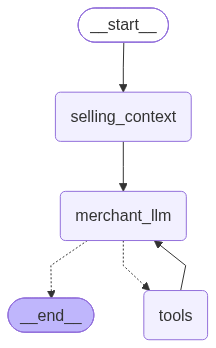

In [12]:
compiled_merchant_graph

## 7. Test Invocations of Full Assembled Graph

In [13]:
# Test invocation: Customer with budget and intent asking for recommendation
test_state = {
    "messages": [HumanMessage(content="I need a watch around Rs 5000 and can stretch Rs 1000 for good quality.")]
}

print("Invoking compiled_merchant_graph...")
response = compiled_merchant_graph.invoke(test_state)
print("\n--- Response Message ---")
print(response["messages"][-1].content)


Invoking compiled_merchant_graph...


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond



--- Response Message ---
Hey there! 👋  
Here are the watches that fit right into your ₹5 000‑₹6 000 budget:

| Product | Price (₹) | Key Highlight |
|---------|-----------|---------------|
| **Apex Active Pulse GPS Watch Gen 2** | **5 999** | Entry‑level GPS smartwatch with 14‑day battery, heart‑rate & SpO₂ monitoring, IP68 water‑resistance. |
| **Apex Active Pulse GPS Watch Gen 7** | **5 499** | Mid‑range model with the same core features, slightly slimmer design and a bit lighter on the wrist. |

Both are from the same “Active Pulse” line, so they share the same solid build quality and health‑tracking specs.  

Which one catches your eye, or do you have a specific feature in mind (e.g., battery life, style, or a particular sport‑tracking mode)? Let me know and I can add it to your cart for you!
